<a href="https://colab.research.google.com/github/sreetamasantra/Students-Performance-Analysis-Prediction-Model/blob/main/DAproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
# Rename columns for convenience
df.columns = df.columns.str.replace(" ", "_")

# Convert categorical variables using encoding
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,math_score,reading_score,writing_score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental_level_of_education_bachelor's degree,parental_level_of_education_high school,parental_level_of_education_master's degree,parental_level_of_education_some college,parental_level_of_education_some high school,lunch_standard,test_preparation_course_none
0,72,72,74,False,True,False,False,False,True,False,False,False,False,True,True
1,69,90,88,False,False,True,False,False,False,False,False,True,False,True,False
2,90,95,93,False,True,False,False,False,False,False,True,False,False,True,True
3,47,57,44,True,False,False,False,False,False,False,False,False,False,False,True
4,76,78,75,True,False,True,False,False,False,False,False,True,False,True,True


        math_score  reading_score  writing_score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203


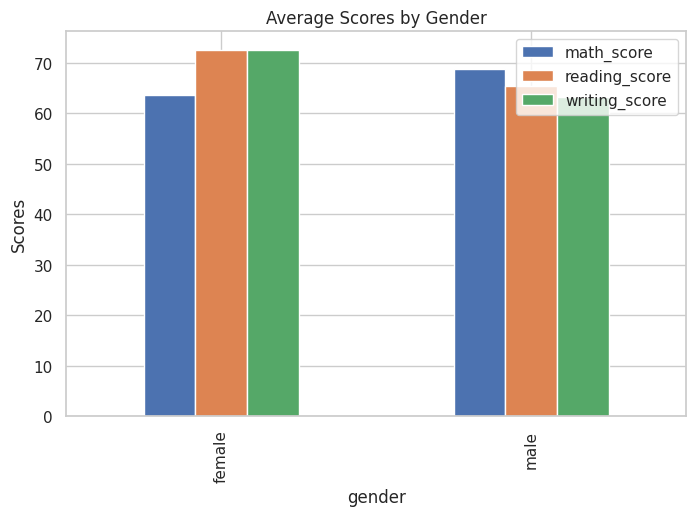

In [ ]:
# Average scores by gender
gender_scores = df.groupby("gender")[["math_score", "reading_score", "writing_score"]].mean()
print(gender_scores)

gender_scores.plot(kind='bar', figsize=(8,5))
plt.title("Average Scores by Gender")
plt.ylabel("Scores")
plt.show()

               math_score  reading_score  writing_score
math_score       1.000000       0.817580       0.802642
reading_score    0.817580       1.000000       0.954598
writing_score    0.802642       0.954598       1.000000


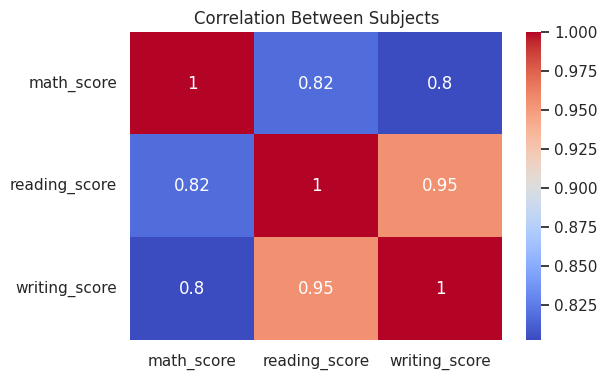

In [ ]:
# Correlation matrix
corr = df[["math_score", "reading_score", "writing_score"]].corr()

print(corr)

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Subjects")
plt.show()

In [ ]:
# Features and target
X = df_encoded.drop("math_score", axis=1)
y = df_encoded["math_score"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 4.214763142474851
R2 Score: 0.8804332983749565


In [ ]:
# Coefficients
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])

# Sort by importance
coeff_df = coeff_df.sort_values(by='Coefficient', ascending=False)

coeff_df.head(10)

,Coefficient
gender_male,13.064884
race/ethnicity_group E,4.892649
lunch_standard,3.510075
test_preparation_course_none,3.289642
parental_level_of_education_some college,0.998856
parental_level_of_education_high school,0.929312
parental_level_of_education_some high school,0.756470
writing_score,0.724148
race/ethnicity_group B,0.359323
reading_score,0.236023


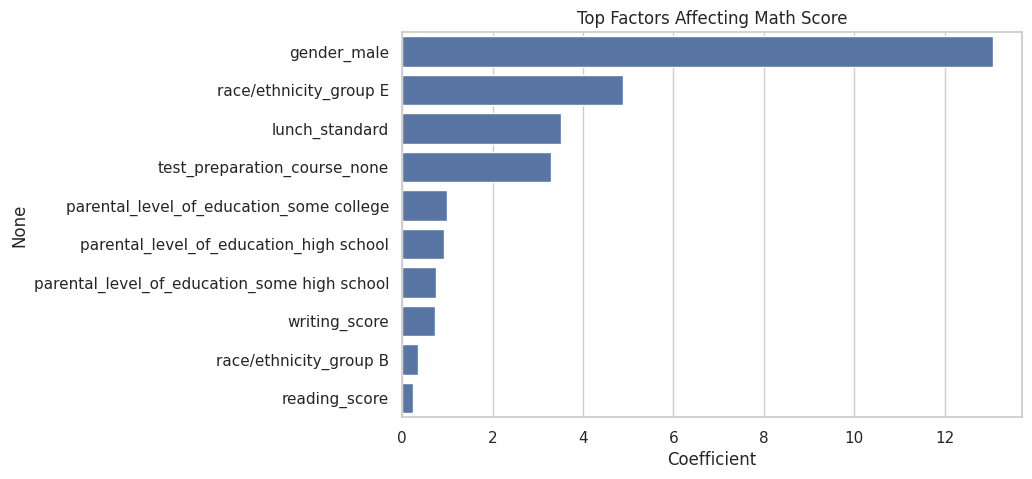

In [ ]:
# Top 10 features
top_features = coeff_df.head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_features["Coefficient"], y=top_features.index)
plt.title("Top Factors Affecting Math Score")
plt.show()

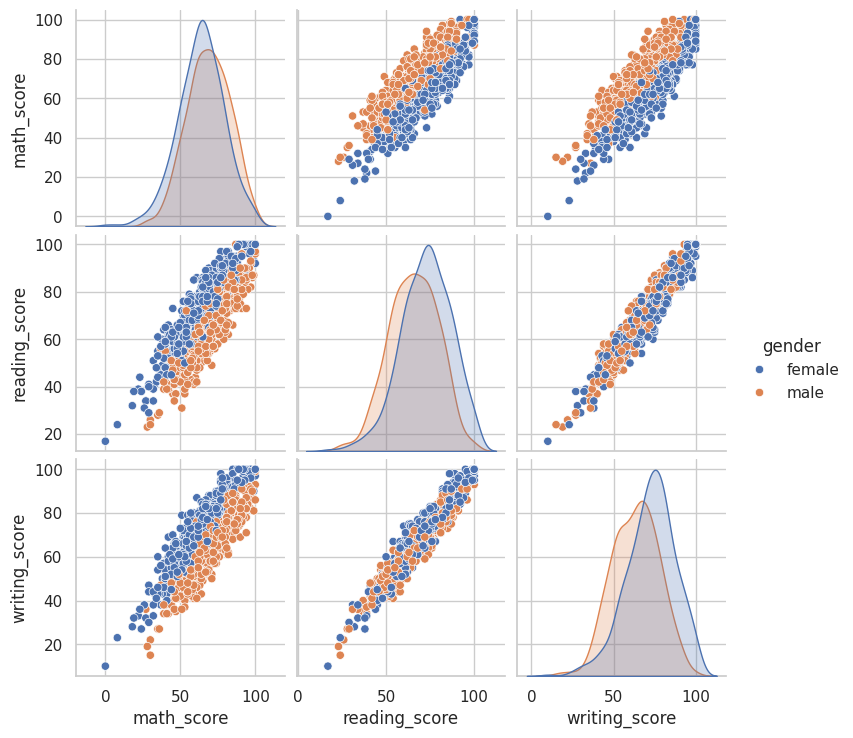

In [ ]:
sns.pairplot(df[["math_score", "reading_score", "writing_score", "gender"]], hue="gender")
plt.show()